# Integration and Plotting

This tutorial covers integrating orbits in potentials, plotting their
trajectories, accessing orbital quantities, and working with
non-inertial reference frames.

In [1]:
%matplotlib inline
import numpy
from astropy import units
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014, LogarithmicHaloPotential

## Basic integration

Use `o.integrate(ts, pot)` to integrate an orbit. The time array `ts`
should start at 0 (the initial condition).

In [2]:
o = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 10.0, 10000)
o.integrate(ts, MWPotential2014)
print("Integration complete. Final R =", o.R(ts[-1]))

Integration complete. Final R = 1.0478229328266577


## Automatic time determination

You can pass just the potential and galpy will integrate for ~10 dynamical times.

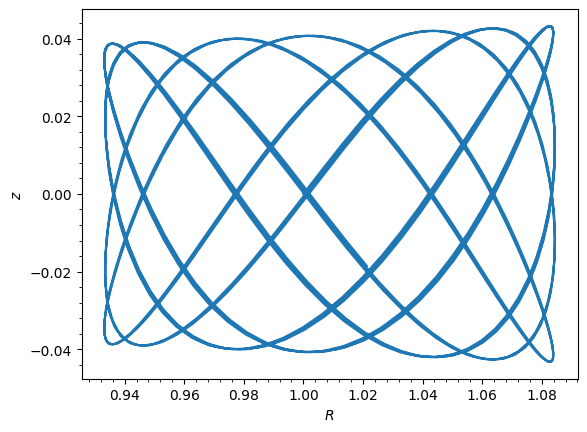

In [3]:
o_auto = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
o_auto.integrate(MWPotential2014)
o_auto.plot()

## Physical units for time

When using `ro=` and `vo=`, you can pass time arrays in physical units.

In [4]:
o_phys = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0], ro=8.0, vo=220.0)
ts_phys = numpy.linspace(0.0, 5.0, 5000) * units.Gyr
o_phys.integrate(ts_phys, MWPotential2014)
print("R at 5 Gyr =", o_phys.R(ts_phys[-1]))

R at 5 Gyr = 7.704903501320295


## Parallel integration of multiple orbits

Multi-orbit objects are integrated in parallel using C.

In [5]:
numpy.random.seed(42)
vxvvs = numpy.column_stack(
    [
        numpy.random.uniform(0.8, 1.2, 100),
        numpy.random.normal(0.0, 0.05, 100),
        numpy.random.uniform(0.9, 1.1, 100),
        numpy.random.normal(0.0, 0.05, 100),
        numpy.random.normal(0.0, 0.05, 100),
        numpy.random.uniform(0.0, 2 * numpy.pi, 100),
    ]
)
os = Orbit(vxvvs)
ts = numpy.linspace(0.0, 10.0, 1001)
os.integrate(ts, MWPotential2014)
print("All", os.size, "orbits integrated.")
print("R shape at all times:", os.R(ts).shape)

  0%|          | 0/100 [00:00<?, ?it/s]

All 100 orbits integrated.
R shape at all times: (100, 1001)


## Continuing integrations

galpy supports *continuing* orbit integrations in both forward and backward time
directions. For forward continuation, if the first time of the new integration
matches the last time of the previous integration, the two are merged into a single
continuous orbit. Backward continuation works similarly: if the first time of the new
integration matches the first time of the previous one and goes in the opposite
direction, the orbit is integrated backward and prepended.

The two time arrays do not need the same number of points or spacing. The only
requirement is that the starting time of the new array matches the appropriate
endpoint of the existing one.

Time range now covers t = -5 to 10


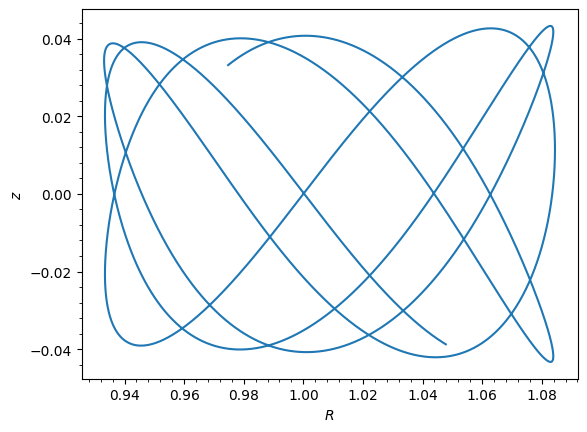

In [6]:
o_cont = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])

# Forward integration
ts_fwd = numpy.linspace(0.0, 5.0, 5000)
o_cont.integrate(ts_fwd, MWPotential2014)

# Continue forward
ts_ext = numpy.linspace(5.0, 10.0, 5000)
o_cont.integrate(ts_ext, MWPotential2014)

# Backward integration from t=0
ts_bwd = numpy.linspace(0.0, -5.0, 5000)
o_cont.integrate(ts_bwd, MWPotential2014)

print("Time range now covers t = -5 to 10")
o_cont.plot()

## Displaying orbits: various projections

Use `o.plot()` with `d1` and `d2` to select projections.

In [7]:
o = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 10.0, 10000)
o.integrate(ts, MWPotential2014)

The default projection is $R$ vs. $z$ (meridional plane):

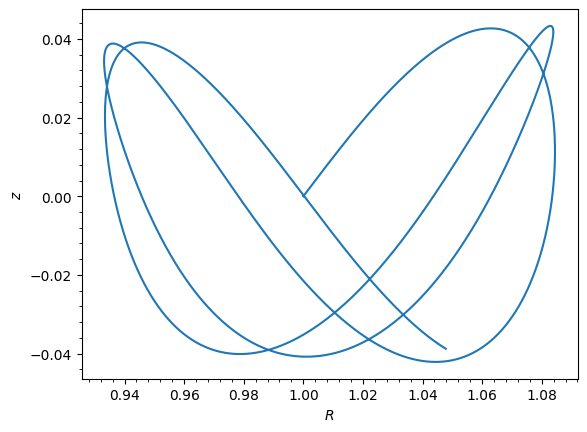

In [8]:
# Default: R vs. z (meridional plane)
o.plot()

Face-on view in the disk plane (`x` vs. `y`):

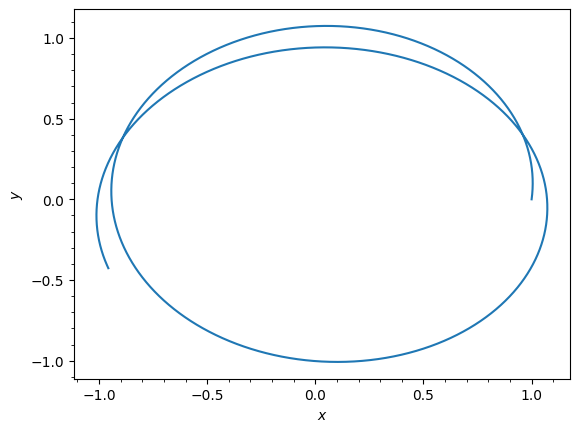

In [9]:
# Face-on view: x vs. y
o.plot(d1="x", d2="y")

Phase-space projections (`R` vs. `vR`):

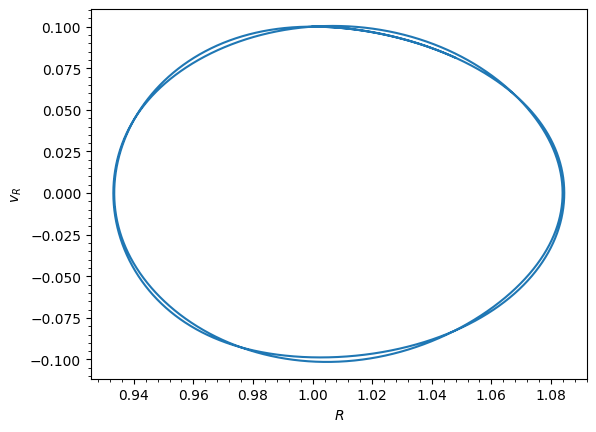

In [10]:
# Phase space: R vs. vR
o.plot(d1="R", d2="vR")

Sky coordinates can also be plotted when `ro` and `vo` are set. Here we plot Galactic `(l, b)`:

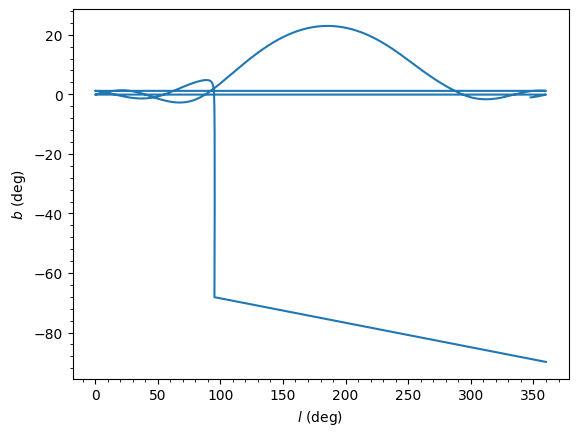

In [11]:
# Sky coordinates (requires ro/vo)
o_sky = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0], ro=8.0, vo=220.0)
o_sky.integrate(ts, MWPotential2014)
o_sky.plot(d1="ll", d2="bb")

And equatorial `(RA, Dec)`:

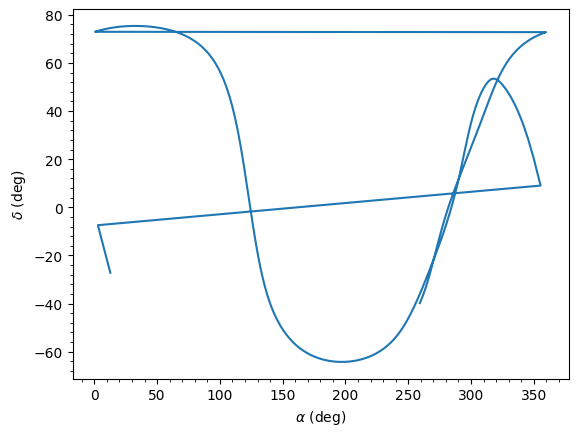

In [12]:
o_sky.plot(d1="ra", d2="dec")

## Custom expression plotting

You can use arbitrary expressions in `o.plot()` calls using `numexpr` syntax (requires the `numexpr` package). For example, `o.plot(d1="t", d2="R*cos(phi)")`. Without `numexpr`, you can compute the quantity manually and use `matplotlib`:

Text(0, 0.5, '$R\\,\\cos\\phi$')

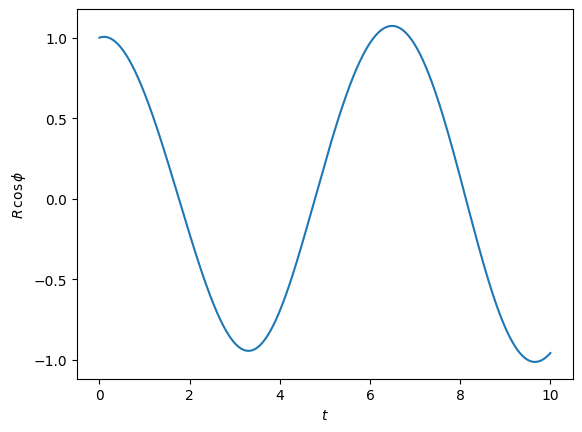

In [13]:
from matplotlib import pyplot as plt

# Equivalent of o.plot(d1="t", d2="R*cos(phi)") without numexpr
ts_plot = o.time(o.t)
R_cos_phi = o.R(o.t) * numpy.cos(o.phi(o.t))
plt.plot(ts_plot, R_cos_phi)
plt.xlabel(r"$t$")
plt.ylabel(r"$R\,\cos\phi$")

## Orbit characterization

After integration, compute orbital parameters numerically.

In [14]:
print("Eccentricity:", o.e())
print("Apocenter:", o.rap())
print("Pericenter:", o.rperi())
print("Max |z|:", o.zmax())

Eccentricity: 0.07484773934372554
Apocenter: 1.0847070212241001
Pericenter: 0.9336384271952163
Max |z|: 0.04328778107544663


These parameters can also be computed analytically using the Staeckel approximation, without any orbit integration (see [Fast Orbit Characterization](fast_characterization.ipynb)):

In [15]:
# Analytic computation using the Staeckel approximation (no integration needed)
o_new = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
print("Analytic e:", o_new.e(analytic=True, pot=MWPotential2014, type="staeckel"))
print("Analytic rap:", o_new.rap(analytic=True, pot=MWPotential2014, type="staeckel"))

Analytic e: 0.07494364311796002
Analytic rap: 1.0844978863649968


## Energy and energy conservation

In [16]:
print("Energy at t=0:", o.E(0.0))
print("Energy at t=10:", o.E(ts[-1]))
print("Relative energy error:", (o.E(ts[-1]) - o.E(0.0)) / abs(o.E(0.0)))

Energy at t=0: -0.8633506513947898
Energy at t=10: -0.8633506513947993
Relative energy error: -1.093054796920349e-14


## Accessing raw orbital data

Evaluate orbital quantities at any time, or get the full array.

In [17]:
# At specific time
print("R(t=5):", o.R(5.0))
print("phi(t=5):", o.phi(5.0))

# Full orbit array: shape (ntimes, ndim)
orbit_array = o.getOrbit()
print("Full orbit shape:", orbit_array.shape)

R(t=5): 1.0248822021703112
phi(t=5): -1.355027550131503
Full orbit shape: (10000, 6)


Sky coordinates are available when `ro` and `vo` are set:

In [18]:
# Sky coordinates at specific time (requires ro/vo)
print("RA(t=5):", o_sky.ra(5.0))
print("Dec(t=5):", o_sky.dec(5.0))

RA(t=5): 204.3700933860206
Dec(t=5): -64.02927160795767


## Creating a new orbit from evaluated position

Calling an orbit as a function returns a new Orbit at that time.

In [19]:
o_at_5 = o(5.0)
print("New orbit at t=5:", o_at_5)
print("R:", o_at_5.R())

New orbit at t=5: <galpy.orbit.Orbits.Orbit object at 0x7a48473b6650>
R: 1.0248822021703112


## Non-inertial frames

galpy supports orbit integration in non-inertial reference frames
using `NonInertialFrameForce`. Here is a brief example of a
rotating frame.

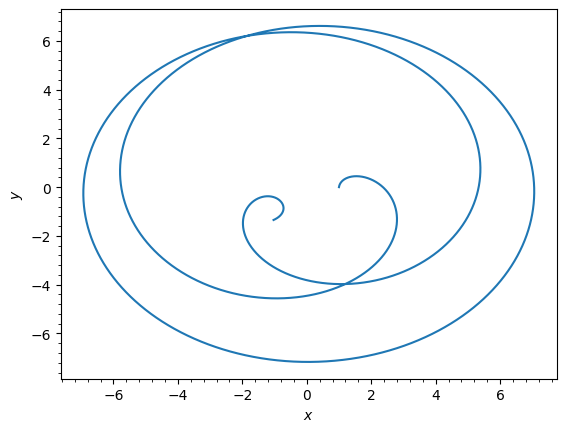

In [20]:
from galpy.potential import NonInertialFrameForce

# Set up a frame rotating at the LSR angular frequency
lp = LogarithmicHaloPotential(normalize=1.0)
nif = NonInertialFrameForce(Omega=1.0)  # Omega = vcirc/R = 1 in natural units

o_rot = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 20.0, 20000)
o_rot.integrate(ts, lp + nif)
o_rot.plot(d1="x", d2="y")

## Surfaces of section

galpy can compute surfaces of section (SOS) for 2D and 3D orbits using a special
integration method that exactly determines intersections between orbits and a surface.

Supported surfaces:
- **3D orbits:** $z=0, v_z>0$ surface
- **2D orbits:** $x=0, v_x>0$ or $y=0, v_y>0$ surfaces

Surfaces of section are most useful for static, axisymmetric potentials (3D) or
static, non-axisymmetric potentials (2D).

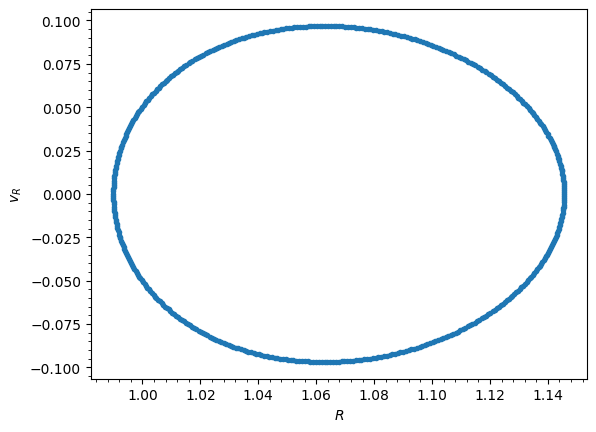

In [21]:
# Surface of section for the Sun's orbit in MWPotential2014
o_sun = Orbit()
o_sun.turn_physical_off()
o_sun.plotSOS(MWPotential2014)

You can also retrieve the SOS crossing values directly using `o.SOS()`:

In [22]:
# Get the SOS values directly
Rs, vRs = o_sun.SOS(MWPotential2014)
print("Number of SOS crossings:", len(Rs))

Number of SOS crossings: 500


For 2D orbits, we can compute surfaces of section in the `x` or `y` planes:

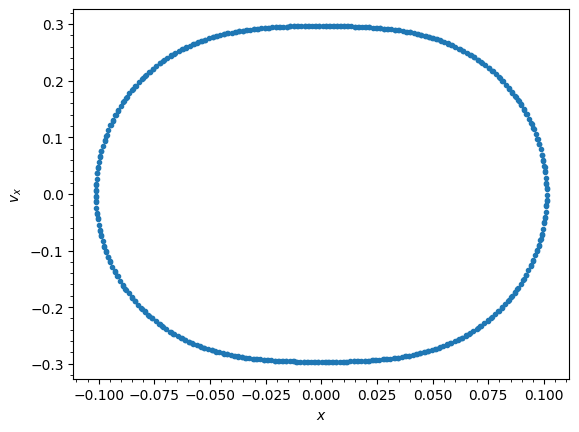

In [23]:
# 2D example: box orbit in a non-axisymmetric cored logarithmic potential
lp_2d = LogarithmicHaloPotential(normalize=True, b=0.9, core=0.2)
orb_2d = Orbit([0.1, 0.0, lp_2d.vcirc(0.1, phi=0.0), numpy.pi / 2.0])
orb_2d.plotSOS(lp_2d, surface="y")

## Integration of the phase-space volume

galpy supports the integration of the phase-space volume through the method
`integrate_dxdv`. This is currently only implemented for two-dimensional orbits
(planar orbits). This can be used to, for example, explicitly verify Liouville's
theorem (that phase-space volume is conserved along the orbit). See the
`integrate_dxdv` API documentation for details.

## Fast orbit integration and available integrators

The standard orbit integration uses scipy integrators in Python. For batch integration
of many orbits, galpy provides fast C integrators accessed via the `method=` keyword.

**C integrators (recommended for speed):**
- `rk4_c`, `rk6_c`: Runge-Kutta methods
- `dopr54_c`, `dop853_c`: Dormand-Prince methods
- `ias15_c`: IAS15 integrator (Rein & Spiegel 2014), adaptive timestepping for high precision

**Symplectic C integrators:**
- `leapfrog_c`, `symplec4_c`, `symplec6_c`

**Pure Python integrators:**
- `leapfrog`, `odeint`, `dop853`

For most applications, `symplec4_c` or `dop853_c` are recommended.

In [24]:
# Check if a potential has a C implementation
from galpy.potential import MiyamotoNagaiPotential as MNP

mp_test = MNP(a=0.5, b=0.0375, amp=1.0, normalize=1.0)
print("MiyamotoNagaiPotential has C:", mp_test.hasC)

# Integrate using the fast dop853_c method
o_fast = Orbit([1.0, 0.1, 1.1, 0.0, 0.1, 0.0])
ts = numpy.linspace(0.0, 100.0, 10001)
o_fast.integrate(ts, MWPotential2014, method="dop853_c")
print("Integration with dop853_c complete.")

MiyamotoNagaiPotential has C: True
Integration with dop853_c complete.
